# SIR model

#Описание модели

Модель описывает рспространение инфекционного заболевания.

## Код модели

In [1]:
using DrWatson
@quickactivate 
using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings # Для красивого отображения формул на графиках
using Plots
using BenchmarkTools
script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))
function sir_ode!(du, u, p, t)
(S, I, R) = u
(β, c, γ) = p
N = S + I + R
@inbounds begin
du[1] = -β * c * I / N * S
du[2] = β * c * I / N * S - γ * I
du[3] = γ * I
end
nothing
end

sir_ode! (generic function with 1 method)

# Параметры модели

In [2]:
δt = 0.1
tmax = 40.0
tspan = (0.0, tmax)
u0 = [990.0, 10.0, 0.0]
p = [0.05, 10.0, 0.25]

3-element Vector{Float64}:
  0.05
 10.0
  0.25

# S, I, R

# β, c, γ

# Расчет базового репродуктивного числа

In [3]:
R0 = (p[2] * p[1]) / p[3] # R0 = (c * β) / γ

2.0

# Создание и решение задачи

In [4]:
prob_ode = ODEProblem(sir_ode!, u0, tspan, p)
sol_ode = solve(prob_ode, dt = δt)

retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
  0.0
  0.1
  0.5331242537191838
  1.3919008491040001
  2.6102120755226386
  4.1811820758323055
  6.180123810566044
  8.664951930903612
 11.691425331813486
 15.279370667110317
 19.082963490744028
 23.423425193442526
 28.42949373098617
 33.298779173639595
 40.0
u: 15-element Vector{Vector{Float64}}:
 [990.0, 10.0, 0.0]
 [989.4990153200853, 10.247898072276143, 0.25308660763853125]
 [987.1852964117763, 11.391111426852984, 1.4235921613706284]
 [981.8312125227972, 14.026022042698546, 4.14276543450428]
 [972.1392310589528, 18.757815561654187, 9.102953379393007]
 [954.9905500491583, 27.007702518267607, 18.00174743257403]
 [923.0706717929863, 41.92976779832721, 34.999560408686385]
 [862.6705810342164, 68.49345419063417, 68.83596477514932]
 [754.3022993851442, 109.74186185409279, 135.9558387607629]
 [595.1014268847736, 150.41363264480682, 254.48494047041947]
 [442.0141179101299, 154.80694988491865, 403.178932204951

# Подготовка данных в DataFrame

In [5]:
df_ode = DataFrame(Tables.table(sol_ode'))
rename!(df_ode, ["S", "I", "R"])
df_ode[!, :t] = sol_ode.t
df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R

15-element Vector{Float64}:
 1000.0
 1000.0
  999.9999999999999
 1000.0
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
  999.9999999999998
 1000.0
 1000.0
 1000.0
 1000.0

# Общая численность

# Вывод параметров модели

In [6]:
println("Параметры модели SIR:")
println("β (вероятность заражения) = ", p[1])
println("c (среднее число контактов) = ", p[2])
println("γ (скорость выздоровления) = ", p[3])
println("R0 = c * β / γ = ", round(R0, digits=3))
println("Средняя продолжительность болезни = ", round(1/p[3],

digits=2), " дней")
println("Начальные условия: S0 = ", u0[1], ", I0 = ", u0[2], ", R0 =

", u0[3])

Параметры модели SIR:
β (вероятность заражения) = 0.05
c (среднее число контактов) = 10.0
γ (скорость выздоровления) = 0.25
R0 = c * β / γ = 2.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S0 = 990.0, I0 = 10.0, R0 =

0.0

# 1. ОСНОВНОЙ ГРАФИК: динамика всех трех групп


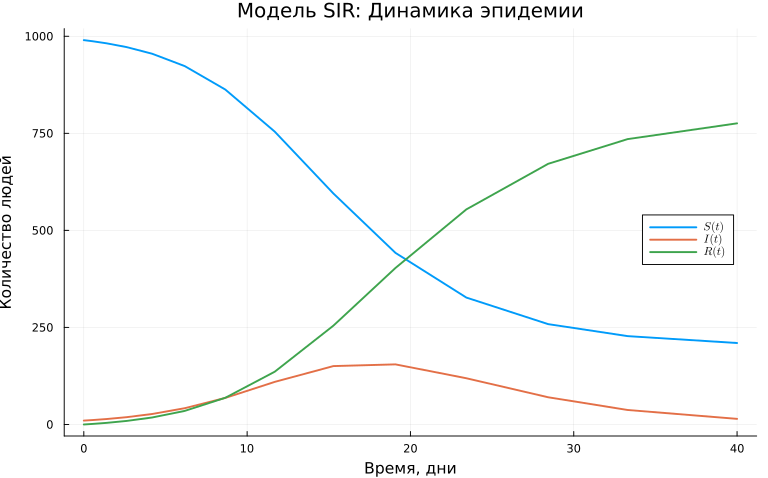

In [7]:
plt1 = @df df_ode plot(:t,
[:S :I :R],
label=[L"S(t)" L"I(t)" L"R(t)"],
xlabel="Время, дни",
ylabel="Количество людей",
title="Модель SIR: Динамика эпидемии",
linewidth=2,
legend=:right,
grid=true,
size=(800, 500))

# Добавление аннотаций с параметрами


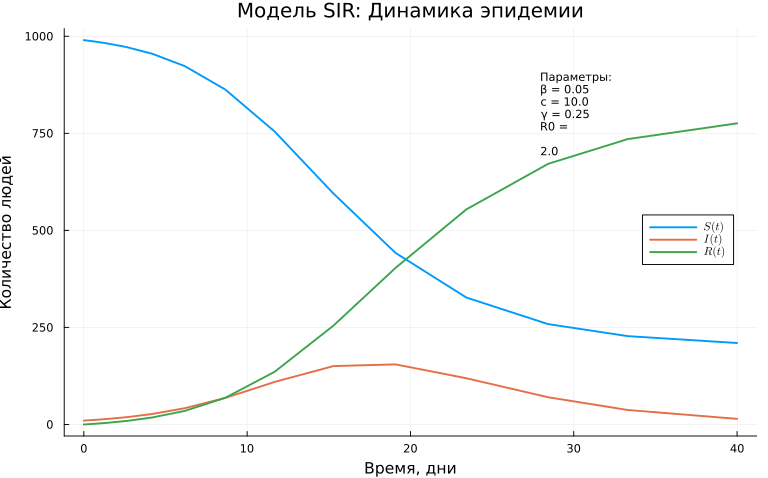

In [8]:
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
text("Параметры:\nβ = $(p[1])\nc = $(p[2])\nγ = $(p[3])\nR0 =

$(round(R0, digits=2))",
8, :left))

# График только инфицированных (I)


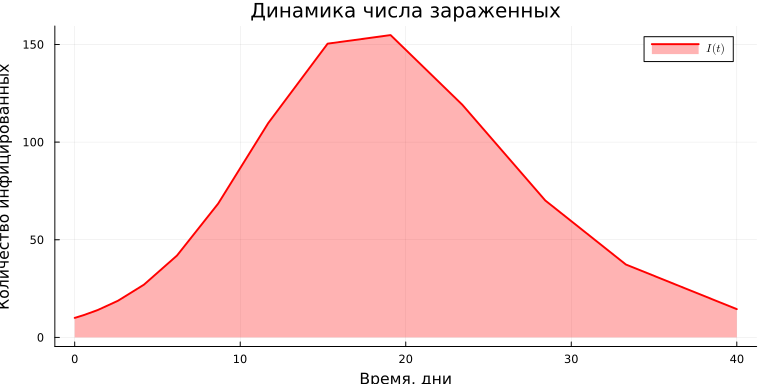

In [9]:
plt2 = @df df_ode plot(:t, :I,
label=L"I(t)",
xlabel="Время, дни",
ylabel="Количество инфицированных",
title="Динамика числа зараженных",
color=:red,
linewidth=2,
fill=(0, 0.3, :red),
grid=true,
size=(800, 400))

# Отметка пика эпидемии


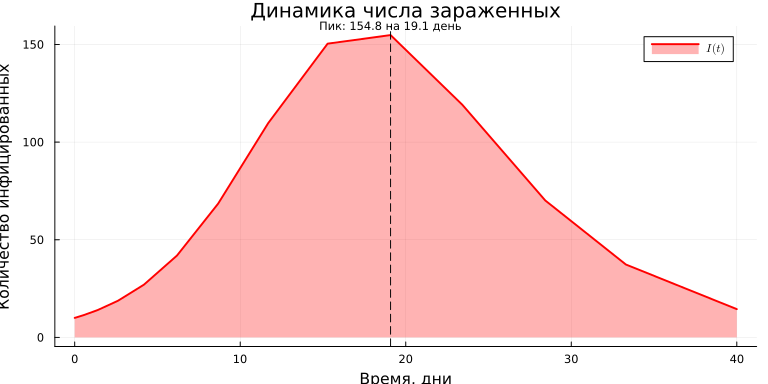

In [10]:
peak_idx = argmax(df_ode.I)
peak_time = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]
vline!(plt2, [peak_time], color=:black, linestyle=:dash,

label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
text("Пик: $(round(peak_value, digits=1)) на $(round(peak_time,

digits=1)) день",
8, :top))

# График в логарифмическом масштабе (для анализа экспоненциального


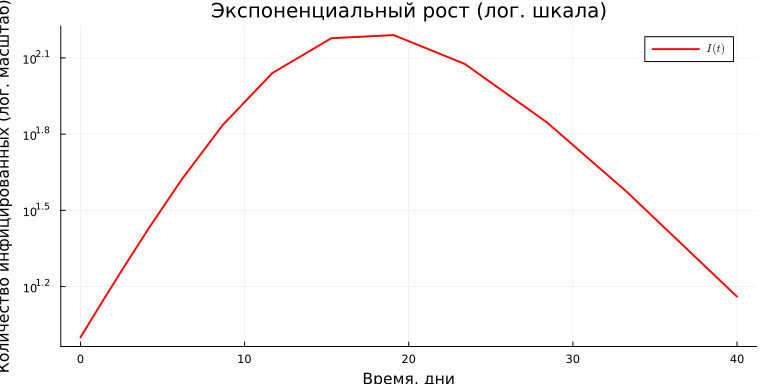

In [11]:
plt3 = @df df_ode plot(:t, :I,
label=L"I(t)",
xlabel="Время, дни",
ylabel="Количество инфицированных (лог. масштаб)",
title="Экспоненциальный рост (лог. шкала)",
yscale=:log10,
color=:red,
linewidth=2,
grid=true,
size=(800, 400))

# График долей населения (в процентах)


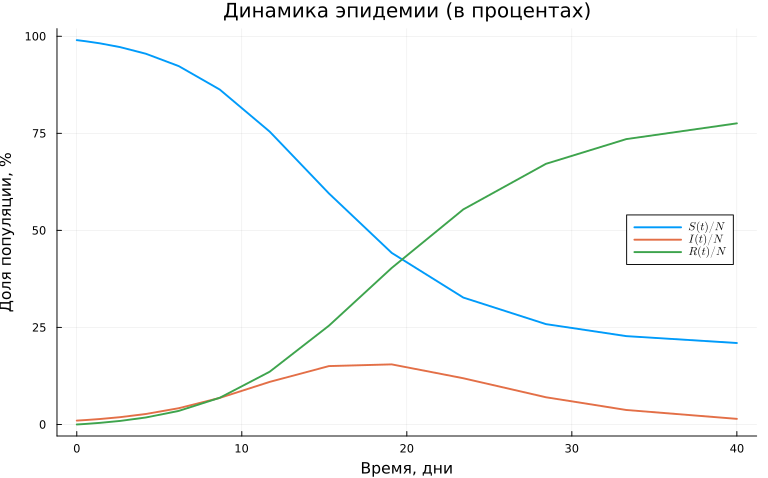

In [12]:
plt4 = @df df_ode plot(:t,
[:S :I :R] ./ df_ode.N .* 100,
label=[L"S(t)/N" L"I(t)/N" L"R(t)/N"],
xlabel="Время, дни",
ylabel="Доля популяции, %",
title="Динамика эпидемии (в процентах)",
linewidth=2,
legend=:right,
grid=true,
size=(800, 500))

# Горизонтальная линия для порога коллективного иммунитета


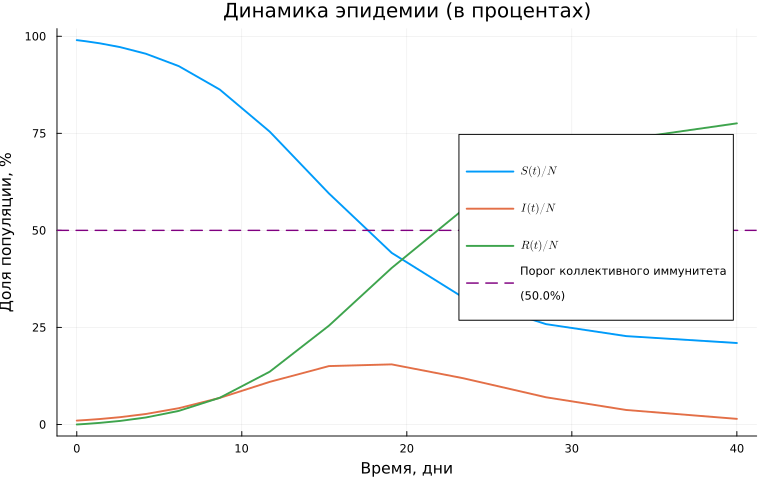

In [13]:
if R0 > 1
herd_immunity_threshold = (1 - 1/R0) * 100
hline!(plt4, [herd_immunity_threshold], color=:purple,

linestyle=:dash,
label="Порог коллективного иммунитета

($(round(herd_immunity_threshold, digits=1))%)",
linewidth=1.5)
end

# Фазовый портрет (I vs S)


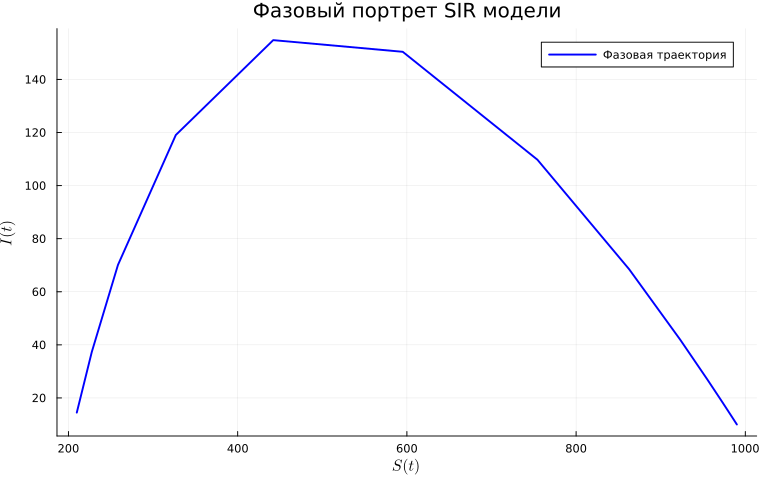

In [14]:
plt5 = plot(df_ode.S, df_ode.I,
label="Фазовая траектория",
xlabel=L"S(t)",
ylabel=L"I(t)",
title="Фазовый портрет SIR модели",
color=:blue,
linewidth=2,
grid=true,
size=(800, 500),
legend=:topright)

# Добавление стрелок направления

In [15]:
for i in 1:50:length(df_ode.S)-1
plot!(plt5, [df_ode.S[i], df_ode.S[i+1]], [df_ode.I[i],

df_ode.I[i+1]],
arrow=:closed, color=:blue, alpha=0.5, label=false)
end

# График Rₑ - эффективного репродуктивного числа


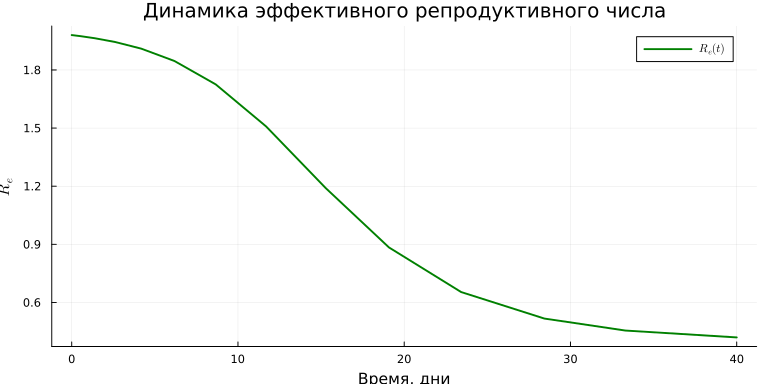

In [16]:
df_ode[!, :Re] = R0 .* df_ode.S ./ df_ode.N
plt6 = @df df_ode plot(:t, :Re,
label=L"R_e(t)",
xlabel="Время, дни",
ylabel=L"R_e",
title="Динамика эффективного репродуктивного числа",
color=:green,
linewidth=2,
grid=true,
size=(800, 400))

# Горизонтальная линия на уровне 1


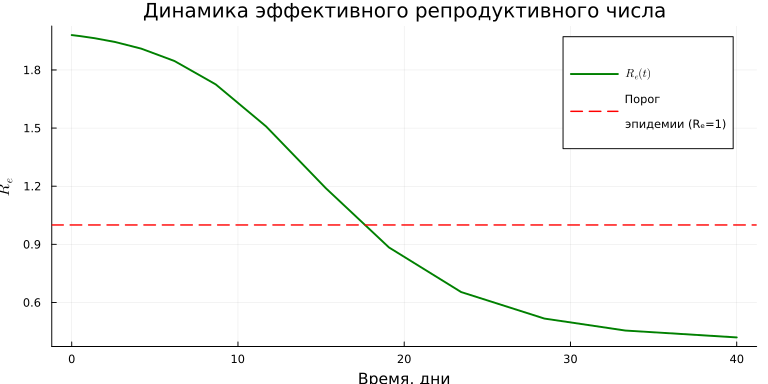

In [17]:
hline!(plt6, [1.0], color=:red, linestyle=:dash, label="Порог

эпидемии (Rₑ=1)", linewidth=1.5)

# Отметка момента, когда Rₑ становится \< 1


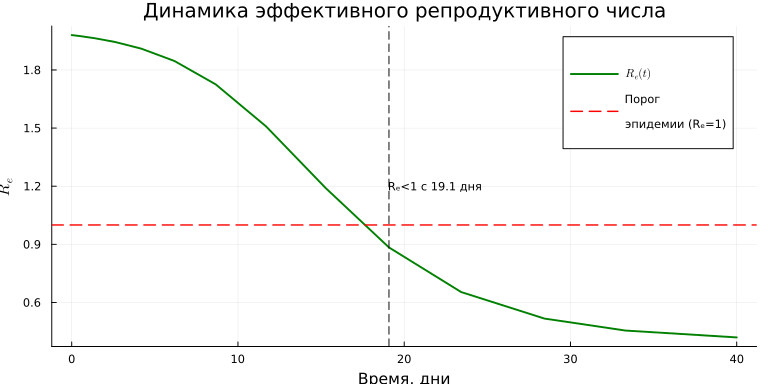

In [18]:
cross_idx = findfirst(x -> x < 1, df_ode.Re)
if !isnothing(cross_idx) && cross_idx > 1
cross_time = df_ode.t[cross_idx]
vline!(plt6, [cross_time], color=:black, linestyle=:dash,

label=false, linewidth=1)
annotate!(plt6, cross_time, 1.2,
text("Rₑ<1 с $(round(cross_time, digits=1)) дня", 8, :left))
end

# Компактный график всех кривых в одной панели


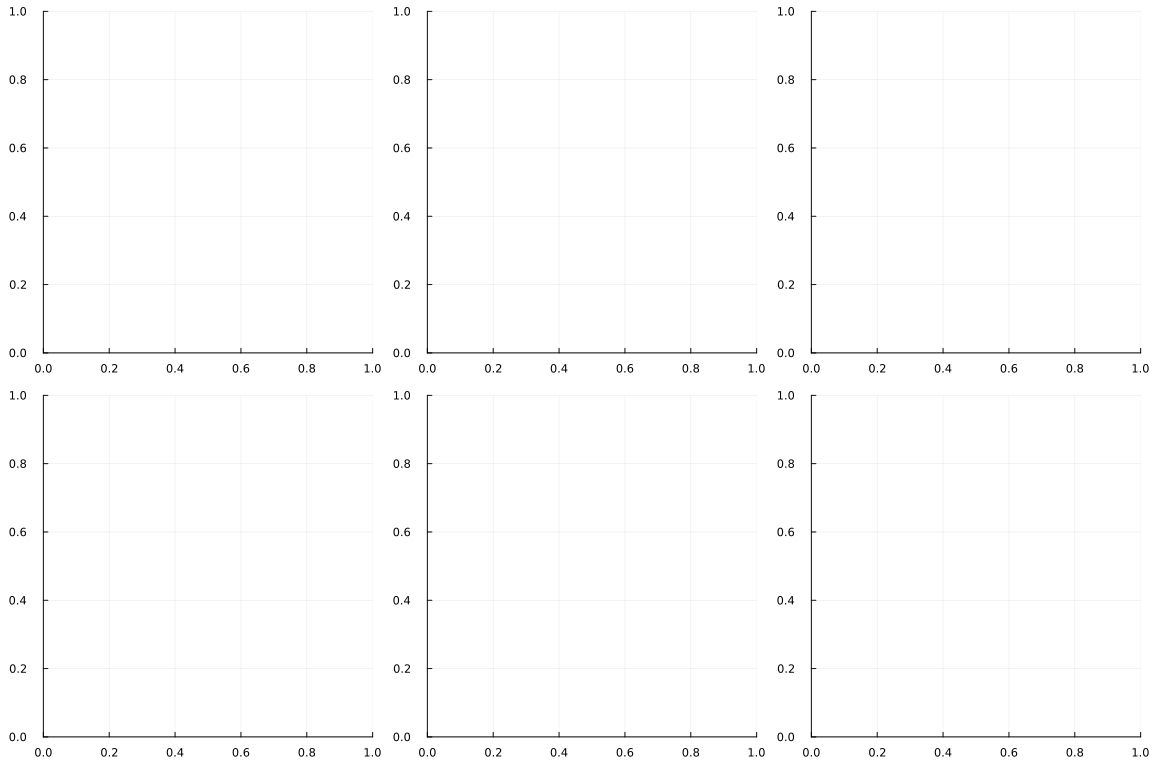

In [19]:
plt7 = plot(layout=(2, 3), size=(1200, 800))

# Верхний ряд


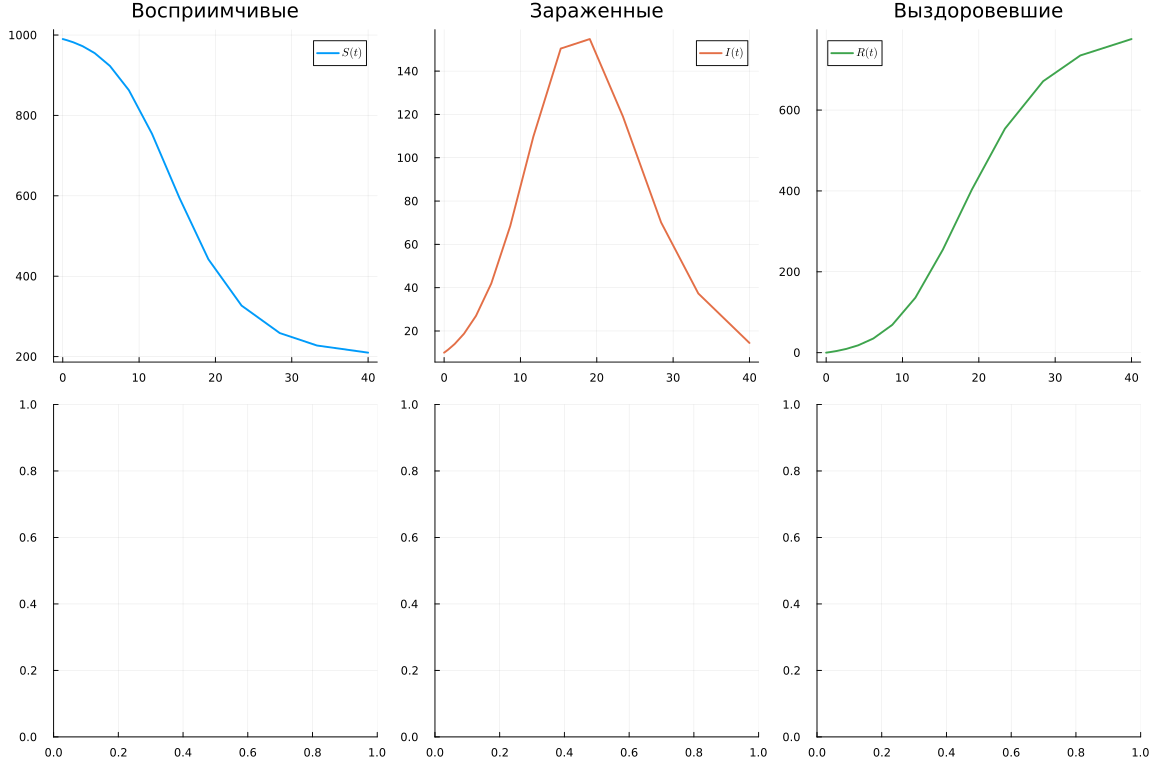

In [20]:
plot!(plt7[1], df_ode.t, df_ode.S, label=L"S(t)", color=1,

linewidth=2, title="Восприимчивые")
plot!(plt7[2], df_ode.t, df_ode.I, label=L"I(t)", color=2,

linewidth=2, title="Зараженные")
plot!(plt7[3], df_ode.t, df_ode.R, label=L"R(t)", color=3,

linewidth=2, title="Выздоровевшие")

# Нижний ряд


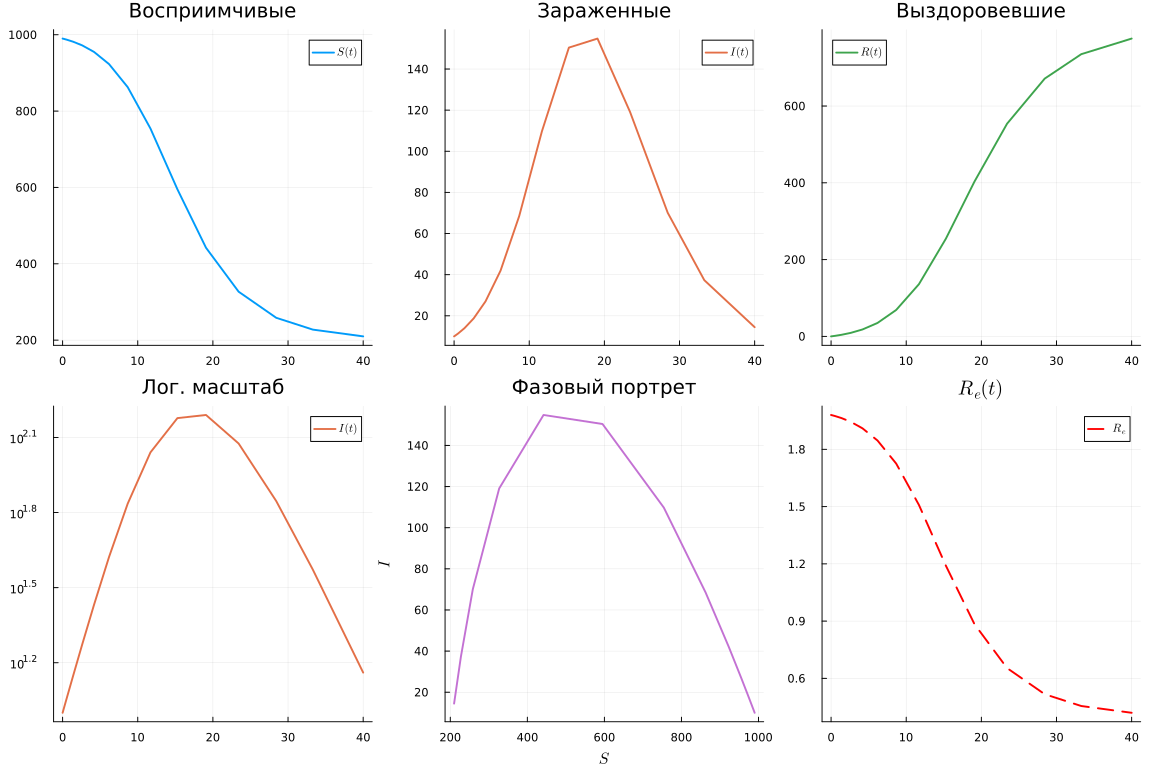

In [21]:
plot!(plt7[4], df_ode.t, df_ode.I, label=L"I(t)", color=2,

linewidth=2,
yscale=:log10, title="Лог. масштаб")
plot!(plt7[5], df_ode.S, df_ode.I, label=false, color=4, linewidth=2,
title="Фазовый портрет", xlabel=L"S", ylabel=L"I")
plot!(plt7[6], df_ode.t, df_ode.Re, label=L"R_e", color=:green,

linewidth=2,
title=L"R_e(t)", hline=[1.0], linestyle=:dash, linecolor=:red)

# Сохранение графиков

In [22]:
savefig(plt1, plotsdir(script_name, "sir_main.png"))
savefig(plt2, plotsdir(script_name, "sir_infected.png"))
savefig(plt3, plotsdir(script_name, "sir_log_scale.png"))
savefig(plt4, plotsdir(script_name, "sir_percentages.png"))
savefig(plt5, plotsdir(script_name, "sir_phase_portrait.png"))
savefig(plt6, plotsdir(script_name, "sir_effective_R.png"))
savefig(plt7, plotsdir(script_name, "sir_panel.png"))

"/home/nurislam/.julia/environments/v1.12/plots/sir_panel.png"

# Бенчмарк для оценки производительности

In [23]:
println("\nБенчмарк решения:")
@benchmark solve(prob_ode, dt = δt)


Бенчмарк решения:

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range ( min … max ): 12.494 μs … 999.447 μs ┊ GC ( min … max ): 0.00% … 0.00%
 Time ( median ): 23.154 μs ┊ GC ( median ): 0.00%
 Time ( mean ± σ ): 35.488 μs ± 58.932 μs ┊ GC ( mean ± σ ): 0.00% ± 0.00%
 ██ █ ▆ ▅ ▃▂▁ ▂
 ██ █ █ █ ███████▇▆▆▇▅▆▆▅▅▄▅▅▅▄▅▆▄▅▄▄▆▅▅▅▆▄▄▆▅▆▅▄▅▅▆▄▄▅▅▅▅▅▄▄▅▆▅▆ █
 12.5 μs Histogram: log( frequency ) by time 335 μs < 
 Memory estimate : 17.39 KiB , allocs estimate : 333 .

# Дополнительный анализ

In [24]:
println("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
println("Общая численность популяции (контроль): N = ",

round(df_ode.N[1], digits=1))
println("Пиковое число зараженных: I_max = ", round(peak_value,

digits=1))
println("Время достижения пика: t_peak = ", round(peak_time,

digits=1), " дней")
println("Итоговое число переболевших: R(∞) = ", round(df_ode.R[end],

digits=1))
println("Доля переболевших: ", round(df_ode.R[end]/df_ode.N[1]*100,

digits=1), "%")
if R0 > 1
println("\nТеоретический анализ:")
println(" - Порог коллективного иммунитета: ",

round((1-1/R0)*100, digits=1), "%")
println(" - Теоретический пик при S/N = 1/R0 = ", round(1/R0,

digits=3))
end


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
Общая численность популяции (контроль): N = 1000.0
Пиковое число зараженных: I_max = 154.8
Время достижения пика: t_peak = 19.1 дней
Итоговое число переболевших: R(∞) = 775.7
Доля переболевших: 77.6%

Теоретический анализ:
 - Порог коллективного иммунитета: 50.0%
 - Теоретический пик при S/N = 1/R0 = 0.5

# Исследование набора параметров

Проведем анализ чувствительности модели к изменению интенсивности
контактов.


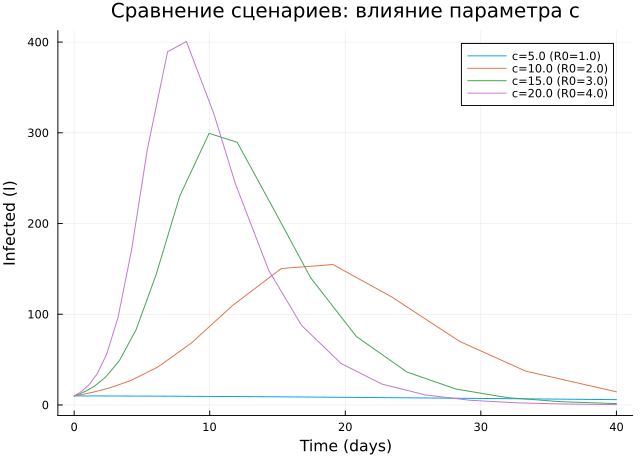

In [25]:
# Очистите этот блок от скрытых символов при вставке
c_variants = [5.0, 10.0, 15.0, 20.0]
plt_sens = plot(title="Сравнение сценариев: влияние параметра c", 
                xlabel="Time (days)", 
                ylabel="Infected (I)", 
                lw=2, grid=true)

for val in c_variants
    # Используем текущие значения u0 и tspan из предыдущих ячеек
    p_test = [p[1], val, p[3]] 
    prob_test = ODEProblem(sir_ode!, u0, tspan, p_test)
    sol_test = solve(prob_test, dt = δt)
    
    R0_val = (val * p[1]) / p[3]
    plot!(plt_sens, sol_test.t, [u[2] for u in sol_test.u], 
          label="c=$val (R0=$(round(R0_val, digits=1)))")
end

display(plt_sens)